# Offline RL Training Analysis

This notebook builds report-ready plots from offline RL training logs and demonstrates practical notebook workflow in VS Code.

## 1. Set Up the Notebook Kernel

In VS Code, select the Python interpreter/kernel for this workspace and run the next cell to verify execution.

In [1]:
print('Kernel is active. Notebook execution works.')

Kernel is active. Notebook execution works.


## 2. Import Core Libraries

Import core analysis libraries and confirm versions.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('matplotlib:', plt.matplotlib.__version__)

numpy: 2.2.6
pandas: 2.3.3
matplotlib: 3.10.6


## 3. Create and Run Basic Python Cells

Demonstrate stateful execution across cells.

In [7]:
run_name = 'offline_rl_analysis'
episode_step = 10

for i in range(1, 4):
    print(f'Run {i}: {run_name} | checkpoint every {episode_step * i} episodes')


def summarize_range(values):
    return {'min': min(values), 'max': max(values), 'mean': float(np.mean(values))}

print(summarize_range([1, 2, 3, 4, 5]))

Run 1: offline_rl_analysis | checkpoint every 10 episodes
Run 2: offline_rl_analysis | checkpoint every 20 episodes
Run 3: offline_rl_analysis | checkpoint every 30 episodes
{'min': 1, 'max': 5, 'mean': 3.0}


## 4. Load a Dataset into a DataFrame

Load offline training logs and inspect schema and summary statistics.

In [8]:
csv_path = 'api/models/rl_offline_episode_log.csv'
out_dir = 'api/models'
os.makedirs(out_dir, exist_ok=True)

df = pd.read_csv(csv_path)
print('shape:', df.shape)
display(df.head())

df.info()
display(df.describe(include='all'))

shape: (501, 16)


,episode,episode_reward_total,episode_reward_avg,cumulative_reward,running_reward_avg,epsilon,episode_dropouts,cumulative_dropouts,q_table_states,training_episodes,action_0_count,action_1_count,action_2_count,action_3_count,action_4_count,action_5_count
0,1,0.431112,0.431112,0.431112,0.431112,0.297007,0,0,3,2,0,0,0,0,0,1
1,10,-0.908147,-0.908147,2.833158,0.283316,0.283906,1,1,17,11,0,0,0,1,0,0
2,20,0.319711,0.319711,5.444118,0.272206,0.270026,0,2,31,21,0,0,0,1,0,0
3,30,0.574299,0.574299,9.767756,0.325592,0.256825,0,2,47,31,0,0,0,1,0,0
4,40,0.307057,0.307057,13.956031,0.348901,0.244269,0,2,61,41,0,0,0,1,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   episode               501 non-null    int64  
 1   episode_reward_total  501 non-null    float64
 2   episode_reward_avg    501 non-null    float64
 3   cumulative_reward     501 non-null    float64
 4   running_reward_avg    501 non-null    float64
 5   epsilon               501 non-null    float64
 6   episode_dropouts      501 non-null    int64  
 7   cumulative_dropouts   501 non-null    int64  
 8   q_table_states        501 non-null    int64  
 9   training_episodes     501 non-null    int64  
 10  action_0_count        501 non-null    int64  
 11  action_1_count        501 non-null    int64  
 12  action_2_count        501 non-null    int64  
 13  action_3_count        501 non-null    int64  
 14  action_4_count        501 non-null    int64  
 15  action_5_count        5

,episode,episode_reward_total,episode_reward_avg,cumulative_reward,running_reward_avg,epsilon,episode_dropouts,cumulative_dropouts,q_table_states,training_episodes,action_0_count,action_1_count,action_2_count,action_3_count,action_4_count,action_5_count
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,2500.001996,0.335407,0.335407,874.254787,0.346926,0.056586,0.075848,168.307385,3710.115768,2501.001996,0.159681,0.157685,0.201597,0.177645,0.151697,0.151697
std,1447.701627,0.360055,0.360055,513.763043,0.008671,0.030537,0.265020,91.414339,2149.970053,1447.701627,0.366676,0.364809,0.401594,0.382595,0.359085,0.359085
min,1.000000,-0.938779,-0.938779,0.431112,0.272206,0.050000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1250.000000,0.337005,0.337005,422.855546,0.343404,0.050000,0.000000,95.000000,1851.000000,1251.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2500.000000,0.427141,0.427141,868.750850,0.348084,0.050000,0.000000,172.000000,3710.000000,2501.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3750.000000,0.507388,0.507388,1321.991847,0.352220,0.050000,0.000000,245.000000,5567.000000,3751.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5000.000000,0.676357,0.676357,1758.935174,0.431112,0.297007,1.000000,327.000000,7427.000000,5001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 5. Transform and Validate Data

Clean, type-cast, derive columns, and run assertions.

In [9]:
df = df.dropna().copy()

numeric_cols = [
    'episode', 'episode_reward_total', 'episode_reward_avg', 'cumulative_reward',
    'running_reward_avg', 'epsilon', 'episode_dropouts', 'cumulative_dropouts',
    'q_table_states', 'training_episodes'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

action_cols = [c for c in df.columns if c.startswith('action_') and c.endswith('_count')]
action_label_map = {
    'action_0_count': 'Increase Workout Frequency',
    'action_1_count': 'Decrease Workout Frequency',
    'action_2_count': 'Increase Meditation Frequency',
    'action_3_count': 'Send Motivational Message',
    'action_4_count': 'Increase Mental Recovery Focus',
    'action_5_count': 'Maintain Current Plan',
}
for col in action_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['dropout_rate_per_episode'] = df['episode_dropouts'] / 1.0

df = df.sort_values('episode').reset_index(drop=True)

assert (df['episode'].diff().fillna(1) >= 0).all(), 'Episodes must be non-decreasing'
assert ((df['epsilon'] >= 0) & (df['epsilon'] <= 1)).all(), 'Epsilon must be in [0,1]'
assert (df['q_table_states'] >= 0).all(), 'Q-table states must be non-negative'

print('Validation passed.')
display(df.head())

Validation passed.


,episode,episode_reward_total,episode_reward_avg,cumulative_reward,running_reward_avg,epsilon,episode_dropouts,cumulative_dropouts,q_table_states,training_episodes,action_0_count,action_1_count,action_2_count,action_3_count,action_4_count,action_5_count,dropout_rate_per_episode
0,1,0.431112,0.431112,0.431112,0.431112,0.297007,0,0,3,2,0,0,0,0,0,1,0.0
1,10,-0.908147,-0.908147,2.833158,0.283316,0.283906,1,1,17,11,0,0,0,1,0,0,1.0
2,20,0.319711,0.319711,5.444118,0.272206,0.270026,0,2,31,21,0,0,0,1,0,0,0.0
3,30,0.574299,0.574299,9.767756,0.325592,0.256825,0,2,47,31,0,0,0,1,0,0,0.0
4,40,0.307057,0.307057,13.956031,0.348901,0.244269,0,2,61,41,0,0,0,1,0,0,0.0


## 6. Visualize Results

Create line, bar, and histogram charts and save them as PNG files.

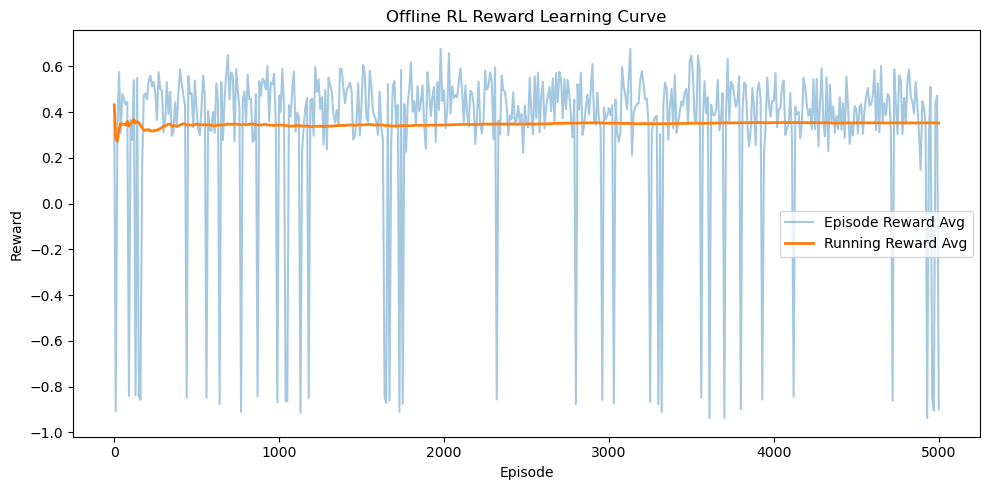

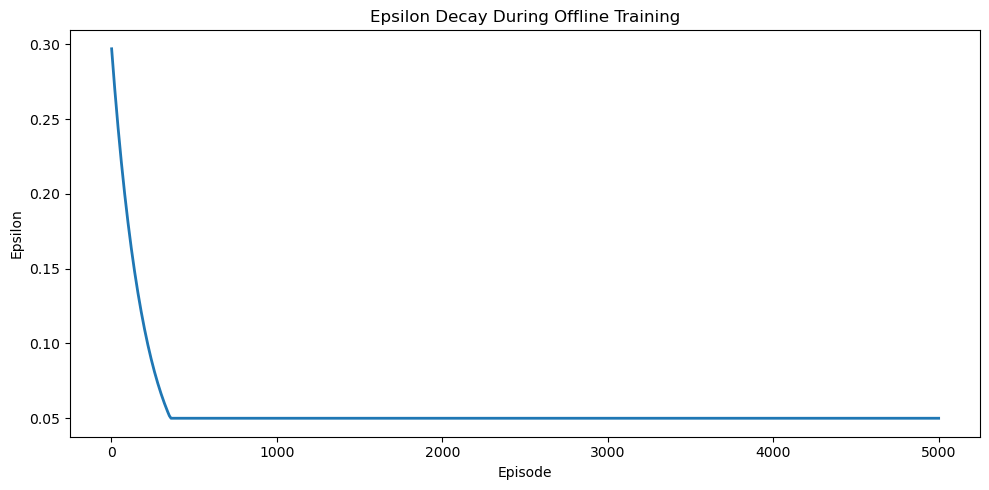

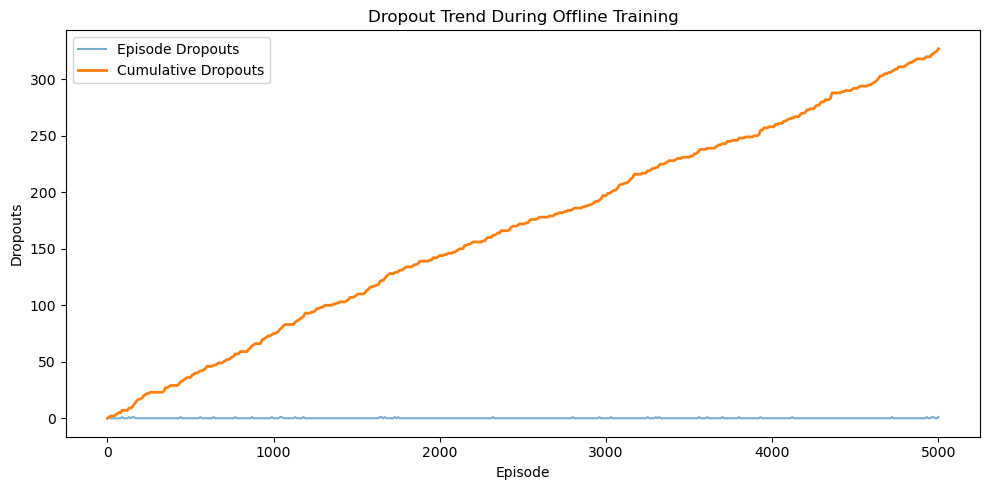

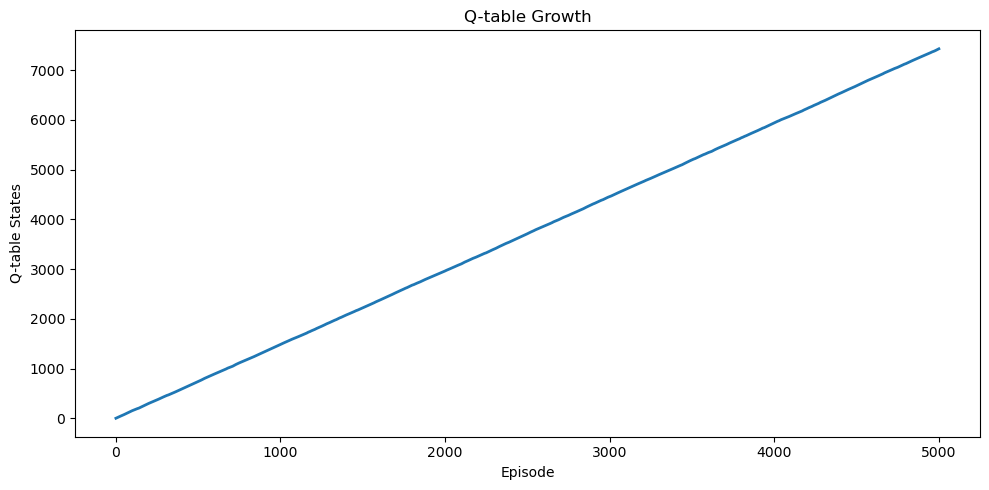

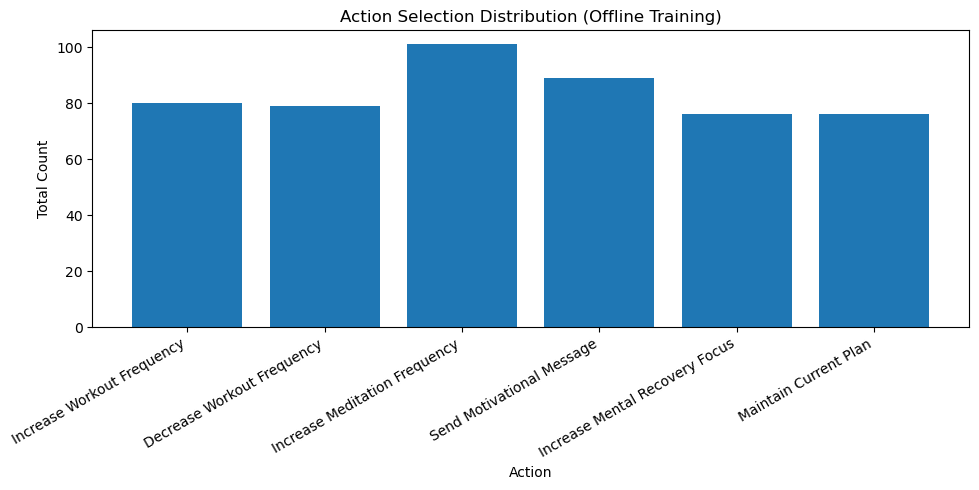

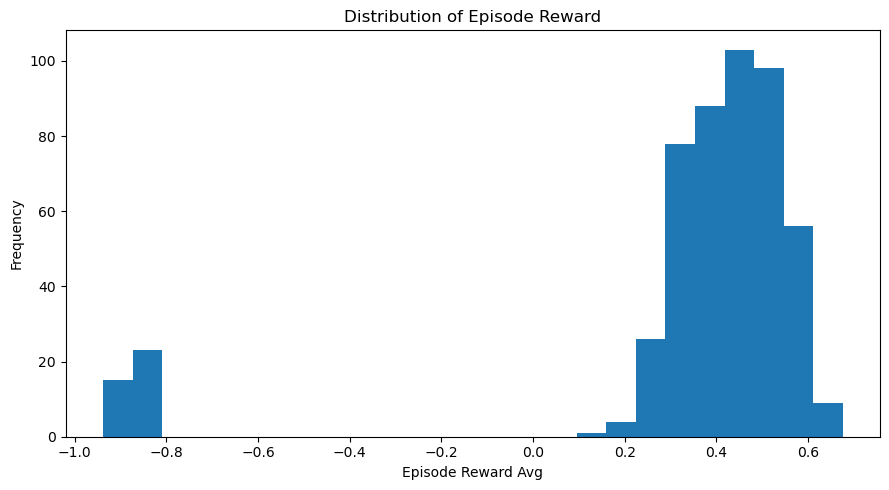

In [10]:
# Line plot: reward learning curve
plt.figure(figsize=(10, 5))
plt.plot(df['episode'], df['episode_reward_avg'], alpha=0.4, label='Episode Reward Avg')
plt.plot(df['episode'], df['running_reward_avg'], linewidth=2, label='Running Reward Avg')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Offline RL Reward Learning Curve')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_curve_reward.png'), dpi=160)
plt.show()

# Line plot: epsilon decay
plt.figure(figsize=(10, 5))
plt.plot(df['episode'], df['epsilon'], linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay During Offline Training')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_curve_epsilon.png'), dpi=160)
plt.show()

# Line plot: dropout trend
plt.figure(figsize=(10, 5))
plt.plot(df['episode'], df['episode_dropouts'], alpha=0.6, label='Episode Dropouts')
plt.plot(df['episode'], df['cumulative_dropouts'], linewidth=2, label='Cumulative Dropouts')
plt.xlabel('Episode')
plt.ylabel('Dropouts')
plt.title('Dropout Trend During Offline Training')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_curve_dropouts.png'), dpi=160)
plt.show()

# Line plot: q-table growth
plt.figure(figsize=(10, 5))
plt.plot(df['episode'], df['q_table_states'], linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Q-table States')
plt.title('Q-table Growth')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_curve_qtable_growth.png'), dpi=160)
plt.show()

# Bar plot: total action distribution with readable labels
action_totals = df[action_cols].sum().sort_index()
action_totals.index = [action_label_map.get(col, col) for col in action_totals.index]
plt.figure(figsize=(10, 5))
plt.bar(action_totals.index, action_totals.values)
plt.xticks(rotation=30, ha='right')
plt.xlabel('Action')
plt.ylabel('Total Count')
plt.title('Action Selection Distribution (Offline Training)')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_action_distribution.png'), dpi=160)
plt.show()

# Histogram: reward distribution
plt.figure(figsize=(9, 5))
plt.hist(df['episode_reward_avg'], bins=25)
plt.xlabel('Episode Reward Avg')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Reward')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'rl_reward_histogram.png'), dpi=160)
plt.show()

## 7. Create Reusable Functions

Refactor repeated plotting logic into reusable helpers.

In [11]:
def save_line_plot(frame, x_col, y_cols, labels, title, y_label, output_name, figsize=(10, 5)):
    plt.figure(figsize=figsize)
    for y_col, label in zip(y_cols, labels):
        plt.plot(frame[x_col], frame[y_col], label=label)
    plt.xlabel(x_col)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    output_path = os.path.join(out_dir, output_name)
    plt.savefig(output_path, dpi=160)
    plt.close()
    return output_path


def save_bar_plot(series, title, x_label, y_label, output_name, figsize=(9, 5)):
    plt.figure(figsize=figsize)
    plt.bar(series.index, series.values)
    plt.xticks(rotation=30, ha='right')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    output_path = os.path.join(out_dir, output_name)
    plt.savefig(output_path, dpi=160)
    plt.close()
    return output_path

sample_path = save_line_plot(
    df,
    x_col='episode',
    y_cols=['running_reward_avg'],
    labels=['Running Reward Avg'],
    title='Running Reward (Reusable Function Demo)',
    y_label='Reward',
    output_name='rl_curve_reward_function_demo.png'
)
print('Saved:', sample_path)

Saved: api/models\rl_curve_reward_function_demo.png


## 8. Run Simple Tests in Notebook Cells

Use lightweight assertions to verify expected structure and behavior.

In [ ]:
required_columns = {
    'episode', 'episode_reward_avg', 'running_reward_avg', 'epsilon',
    'episode_dropouts', 'cumulative_dropouts', 'q_table_states'
}

assert required_columns.issubset(set(df.columns)), 'Missing required columns in CSV'
assert len(df) > 0, 'DataFrame should not be empty'
assert df['episode'].iloc[-1] >= df['episode'].iloc[0], 'Episode index should progress'

# Optional quick sanity check for helper output using readable labels
test_action_totals = df[action_cols].sum().sort_index()
test_action_totals.index = [action_label_map.get(col, col) for col in test_action_totals.index]
bar_out = save_bar_plot(
    test_action_totals,
    title='Action Counts (Test)',
    x_label='Action',
    y_label='Count',
    output_name='rl_action_distribution_test.png'
)
assert os.path.exists(bar_out), 'Expected test plot file was not created'

print('Notebook tests passed.')

## 9. Save the `.ipynb` and Export to `.py`

1. Save this notebook.
2. Run all cells to generate the PNG outputs.
3. In VS Code, use **Export** to save a Python script copy, or run the next cell for an automatic script export.

In [ ]:
generated_pngs = sorted([
    os.path.join(out_dir, f)
    for f in os.listdir(out_dir)
    if f.lower().endswith('.png') and f.startswith('rl_')
])

print('Generated PNG files:')
for p in generated_pngs:
    print('-', p)

py_export_path = 'rl_offline_plots_export.py'
export_lines = [
    'import os',
    'import numpy as np',
    'import pandas as pd',
    'import matplotlib.pyplot as plt',
    '',
    "csv_path = 'api/models/rl_offline_episode_log.csv'",
    "out_dir = 'api/models'",
    'os.makedirs(out_dir, exist_ok=True)',
    'df = pd.read_csv(csv_path)',
    "print('rows:', len(df))",
]
with open(py_export_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(export_lines) + '\n')

print('Exported starter script:', py_export_path)